In [ ]:
# Colab extension helps make the data tables look cleaner.
%load_ext google.colab.data_table

The google.colab.data_table extension is already loaded. To reload it, use:
  %reload_ext google.colab.data_table


# (Run this everytime you run code that calls data from the google drive!)

## Load Data

  

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from google.colab import drive

drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os, glob
import numpy as np
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

# Auto-locate the project folder by finding the raw dataset (handles any folder name)
hits = glob.glob("/content/drive/MyDrive/**/World-Stock-Prices-Dataset.csv", recursive=True)
if not hits:
    raise FileNotFoundError(
        "Dataset not found. In Drive: Shared with me -> right-click the project folder "
        "-> Organize -> Add shortcut to Drive -> My Drive, then re-run this cell."
    )

RAW_DATA_PATH       = os.path.dirname(hits[0])          # .../raw_data
PROJECT_PATH        = os.path.dirname(RAW_DATA_PATH)    # the project folder
PROCESSED_DATA_PATH = os.path.join(PROJECT_PATH, "processed_data")
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

df = pd.read_csv(hits[0])
print("PROJECT_PATH:", PROJECT_PATH)
print("Data Loaded successfully!", df.shape)

ValueError: Mountpoint must not already contain files

### Data Filtering for 'World-Stock-Prices' 2000-2025 Dataset (David)



In [ ]:
import pandas as pd
import os

# The 4 companies we're using

target_tickers = ['AAPL', 'AMZN', 'NVDA', 'TSLA']

filtered_df = df[df['Ticker'].isin(target_tickers)].copy()

filtered_df['Date'] = pd.to_datetime(
    filtered_df['Date'],
    errors='coerce',
    utc=True
).dt.tz_convert(None).dt.normalize()

columns_to_remove = [
    'Dividends',
    'Stock Splits',
    'Brand_Name',
    'Industry_Tag',
    'Country'
]

cleaned_df = filtered_df.drop(
    columns=columns_to_remove,
    errors='ignore'
)

cleaned_df = cleaned_df.dropna(
    subset=['Ticker', 'Date', 'Close']
)

duplicate_rows = cleaned_df.duplicated(
    subset=['Ticker', 'Date'],
    keep=False
).sum()

cleaned_df = cleaned_df.drop_duplicates(
    subset=['Ticker', 'Date'],
    keep='last'
)

cleaned_df = cleaned_df.sort_values(
    by=['Ticker', 'Date']
).reset_index(drop=True)

os.makedirs(
    PROCESSED_DATA_PATH,
    exist_ok=True
)

cleaned_stock_path = os.path.join(
    PROCESSED_DATA_PATH,
    'cleaned_stock_prices.csv'
)

cleaned_df.to_csv(
    cleaned_stock_path,
    index=False
)

# results
print(f"Timeline: {cleaned_df['Date'].min()} to {cleaned_df['Date'].max()}")
print(f"File saved to: {cleaned_stock_path}")

# cleaned_df.head()


Timeline: 2000-01-03 00:00:00 to 2025-07-03 00:00:00
File saved to: /content/drive/MyDrive/Group-04 ML Project/processed_data/cleaned_stock_prices.csv


### Data Filtering for 'US Capital Markets News Headlines 2020 to 2024' Dataset (David)



- This will later be compared with the stocktwits data to see if more reliable news better predicts market movement


In [ ]:
import pandas as pd
import os

# Load dataset

news_path = os.path.join(RAW_DATA_PATH, "news_data.csv")
news_df = pd.read_csv(news_path)


news_df = news_df.rename(
    columns={'symbol': 'Ticker', 'datetime': 'Published_At'}
)


news_df['Ticker'] = (
    news_df['Ticker']
    .astype('string')
    .str.upper()
    .str.strip()
)


target_tickers = ['AAPL', 'AMZN', 'NVDA', 'TSLA']

clean_news_df = news_df[
    news_df['Ticker'].isin(target_tickers)
].copy()


clean_news_df['Published_At'] = (
    pd.to_datetime(
        clean_news_df['Published_At'],
        errors='coerce',
        utc=True
    )
    .dt.tz_convert('America/New_York')
    .dt.tz_localize(None)
)


clean_news_df['Date'] = (
    clean_news_df['Published_At']
    .dt.normalize()
)


clean_news_df['headline'] = (
    clean_news_df['headline']
    .astype('string')
    .str.replace(r"'{2,}", "'", regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)


clean_news_df['source'] = (
    clean_news_df['source']
    .astype('string')
    .str.strip()
)


clean_news_df = clean_news_df.dropna(
    subset=['Ticker', 'Published_At', 'Date', 'headline']
)

clean_news_df = clean_news_df[
    clean_news_df['headline'] != ''
]


duplicates_removed = clean_news_df.duplicated(
    subset=['Ticker', 'uuid']
).sum()

clean_news_df = clean_news_df.drop_duplicates(
    subset=['Ticker', 'uuid']
)


columns_to_keep = [
    'Ticker',
    'Published_At',
    'Date',
    'headline',
    'source'
]

metadata_columns_removed = (
    clean_news_df.shape[1] - len(columns_to_keep)
)

clean_news_df = clean_news_df[columns_to_keep]

clean_news_df = clean_news_df.sort_values(
    by=['Ticker', 'Date', 'Published_At']
).reset_index(drop=True)

# Saves the curated news data in processed_data

os.makedirs(
    PROCESSED_DATA_PATH,
    exist_ok=True
)

cleaned_news_path = os.path.join(
    PROCESSED_DATA_PATH,
    'cleaned_news_data.csv'
)

clean_news_df.to_csv(
    cleaned_news_path,
    index=False
)


# Results

print(f"Timeline spans from {clean_news_df['Date'].min()} to {clean_news_df['Date'].max()}")
print(f"File saved to: {cleaned_news_path}")

Timeline spans from 2023-04-05 00:00:00 to 2024-04-05 00:00:00
File saved to: /content/drive/MyDrive/Group-04 ML Project/processed_data/cleaned_news_data.csv


### Data Filtering for 'StockTwits Post Data' 2020-2022 Dataset (David)



In [ ]:
import pandas as pd
import os

target_tickers = ["AAPL", "AMZN", "NVDA", "TSLA"]
chunk_size = 50000

stocktwits_path = os.path.join(RAW_DATA_PATH, "stocktwits_data")
output_file = os.path.join(PROCESSED_DATA_PATH, "cleaned_stocktwits_posts.csv")

columns_to_read = [
    "id", "body", "created_at", "user", "symbols",
    "entities", "likes", "reshares", "conversation"
]

final_columns = [
    "Post_ID", "Ticker", "Created_At", "Date", "Post_Text",
    "Sentiment", "Mentioned_Tickers", "Symbol_Count",
    "Followers", "Ideas", "Likes", "Reshares", "Replies"
]

os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

all_files = []

for root, folders, files in os.walk(stocktwits_path):
    for file_name in files:
        ticker = file_name.split("_")[0].upper()

        if file_name.lower().endswith(".csv") and ticker in target_tickers:
            all_files.append(os.path.join(root, file_name))

all_files.sort()

if len(all_files) == 0:
    raise FileNotFoundError(f"No StockTwits CSV files found in {stocktwits_path}")

print(f"Found {len(all_files)} files to process.")

def get_nested_value(value, possible_keys):
    if pd.isna(value):
        return None

    text = str(value)

    for key in possible_keys:
        marker = f"'{key}':"

        if marker in text:
            answer = text.split(marker, 1)[1].strip()

            if answer.startswith("'"):
                return answer[1:].split("'", 1)[0]

            answer = answer.split(",", 1)[0]
            answer = answer.split("}", 1)[0]
            answer = answer.split("]", 1)[0]
            return answer.strip()

    return None


def make_number(value, missing_value=pd.NA):
    try:
        return max(int(float(value)), 0)
    except (TypeError, ValueError):
        return missing_value


def get_user_info(value):
    followers = get_nested_value(value, ["followers", "followers_count"])
    ideas = get_nested_value(value, ["ideas", "ideas_count"])
    return make_number(followers), make_number(ideas)


def get_symbols(value):
    if pd.isna(value):
        return "", 0

    symbols = []
    parts = str(value).split("'symbol': '")[1:]

    for part in parts:
        symbol = part.split("'", 1)[0].strip().upper().lstrip("$")

        if symbol and symbol not in symbols:
            symbols.append(symbol)

    return "|".join(symbols), len(symbols)


def get_sentiment(value):
    text = str(value).lower()

    if "bullish" in text:
        return "Bullish"
    if "bearish" in text:
        return "Bearish"
    return "Unknown"


def get_engagement(value, possible_keys):
    number = get_nested_value(value, possible_keys)
    return make_number(number, 0)


def clean_post_text(value):
    if pd.isna(value):
        return pd.NA

    text = str(value)
    text = text.replace("&#39;", "'")
    text = text.replace("&quot;", '"')
    text = text.replace("&amp;", "&")
    text = text.replace("&gt;", ">")
    text = text.replace("&lt;", "<")
    text = " ".join(text.split())

    return text if text else pd.NA

if os.path.exists(output_file):
    os.remove(output_file)

first_chunk = True
rows_read = 0
rows_saved = 0
invalid_rows = 0
duplicate_rows = 0

seen_post_ids = {ticker: set() for ticker in target_tickers}
ticker_counts = {ticker: 0 for ticker in target_tickers}
sentiment_counts = {"Bullish": 0, "Bearish": 0, "Unknown": 0}

for file_number, file_path in enumerate(all_files, start=1):
    ticker = os.path.basename(file_path).split("_")[0].upper()
    print(f"Processing file {file_number} of {len(all_files)}: {ticker}")

    chunks = pd.read_csv(
        file_path,
        usecols=columns_to_read,
        chunksize=chunk_size,
        low_memory=False
    )

    for chunk in chunks:
        starting_rows = len(chunk)
        rows_read += starting_rows

        chunk = chunk.rename(columns={
            "id": "Post_ID",
            "body": "Post_Text",
            "created_at": "Created_At"
        })

        chunk["Ticker"] = ticker
        chunk["Post_ID"] = chunk["Post_ID"].astype("string").str.strip()
        chunk["Post_Text"] = chunk["Post_Text"].apply(clean_post_text)

        chunk["Created_At"] = pd.to_datetime(
            chunk["Created_At"], errors="coerce", utc=True
        )
        chunk["Created_At"] = (
            chunk["Created_At"]
            .dt.tz_convert("America/New_York")
            .dt.tz_localize(None)
        )
        chunk["Date"] = chunk["Created_At"].dt.date

        user_info = chunk["user"].apply(get_user_info)
        chunk["Followers"] = pd.array([x[0] for x in user_info], dtype="Int64")
        chunk["Ideas"] = pd.array([x[1] for x in user_info], dtype="Int64")

        symbol_info = chunk["symbols"].apply(get_symbols)
        chunk["Mentioned_Tickers"] = [x[0] for x in symbol_info]
        chunk["Symbol_Count"] = [x[1] for x in symbol_info]

        chunk["Sentiment"] = chunk["entities"].apply(get_sentiment)
        chunk["Likes"] = chunk["likes"].apply(
            lambda x: get_engagement(x, ["total", "count", "like_count"])
        )
        chunk["Reshares"] = chunk["reshares"].apply(
            lambda x: get_engagement(x, ["reshared_count", "reshare_count"])
        )
        chunk["Replies"] = chunk["conversation"].apply(
            lambda x: get_engagement(x, ["replies", "reply_count"])
        )

        chunk = chunk.dropna(
            subset=["Post_ID", "Post_Text", "Created_At", "Date"]
        )
        chunk = chunk[chunk["Post_ID"] != ""].copy()
        invalid_rows += starting_rows - len(chunk)

        rows_before_duplicates = len(chunk)
        chunk = chunk.drop_duplicates(subset=["Post_ID"])
        chunk = chunk[
            ~chunk["Post_ID"].isin(seen_post_ids[ticker])
        ].copy()
        duplicate_rows += rows_before_duplicates - len(chunk)
        seen_post_ids[ticker].update(chunk["Post_ID"].tolist())

        if chunk.empty:
            continue

        chunk = chunk[final_columns]
        rows_saved += len(chunk)
        ticker_counts[ticker] += len(chunk)

        for sentiment, count in chunk["Sentiment"].value_counts().items():
            sentiment_counts[sentiment] += int(count)

        chunk.to_csv(
            output_file,
            mode="a",
            index=False,
            header=first_chunk,
            compression={"method": "gzip", "compresslevel": 1},
            date_format="%Y-%m-%d %H:%M:%S"
        )
        first_chunk = False

# results

    print("\nData cleaning complete!")

    print("\nSentiment counts:")
for sentiment, count in sentiment_counts.items():
    print(f"{sentiment}: {count:,}")

    print(f"\nFile saved to: {output_file}")
    print(f"show rows read drive {rows_read}")


Found 334 files to process.
Processing file 1 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 2 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 3 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 4 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 5 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 6 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 7 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 8 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 9 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 10 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 11 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 12 of 334: AAPL

Data cleaning complete!

Sentiment counts:
Processing file 13 of 334: AAPL

Data cleaning complete!

Sentiment c


## Feature Engineering and Merging the datasets together (David,Jasleen )

- put the raw stock data into comparative percentage ratios, then merge them directly with StockTwits sentiment data by Date and Ticker.


In [31]:
import pandas as pd
import numpy as np
import os

posts = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "cleaned_stocktwits_posts.csv"), compression="gzip")

posts["Date"] = pd.to_datetime(posts["Date"], errors="coerce").dt.strftime("%Y-%m-%d")
posts["Sentiment"] = posts["Sentiment"].astype("string").str.strip().str.capitalize()
posts["Sentiment"] = posts["Sentiment"].where(posts["Sentiment"].isin(["Bullish", "Bearish"]), "Unknown")
posts = posts.dropna(subset=["Ticker", "Date"])

daily = posts.groupby(["Ticker", "Date"]).agg(
    Total_Posts=("Sentiment", "size"),
    Bullish_Posts=("Sentiment", lambda s: (s == "Bullish").sum()),
    Bearish_Posts=("Sentiment", lambda s: (s == "Bearish").sum()),
    Unknown_Posts=("Sentiment", lambda s: (s == "Unknown").sum()),
).reset_index()

daily["Labeled_Posts"]     = daily["Bullish_Posts"] + daily["Bearish_Posts"]
daily["Bullish_Ratio"]     = daily["Bullish_Posts"] / daily["Total_Posts"]
daily["Bearish_Ratio"]     = daily["Bearish_Posts"] / daily["Total_Posts"]
daily["Unknown_Ratio"]     = daily["Unknown_Posts"] / daily["Total_Posts"]
daily["Average_Sentiment"] = (daily["Bullish_Posts"] - daily["Bearish_Posts"]) / daily["Total_Posts"]

daily = daily[[
    "Ticker", "Date", "Total_Posts", "Labeled_Posts",
    "Bullish_Posts", "Bearish_Posts", "Unknown_Posts",
    "Bullish_Ratio", "Bearish_Ratio", "Unknown_Ratio", "Average_Sentiment"
]].sort_values(["Ticker", "Date"]).reset_index(drop=True)

output_path = os.path.join(PROCESSED_DATA_PATH, "cleaned_stocktwits_daily.csv")
daily.to_csv(output_path, index=False)
print("Daily sentiment file created:", daily.shape)
print("Saved to:", output_path)
daily.head()

Daily sentiment file created: (5608, 11)
Saved to: /content/drive/MyDrive/Group-04 ML Project/processed_data/cleaned_stocktwits_daily.csv


,Ticker,Date,Total_Posts,Labeled_Posts,Bullish_Posts,Bearish_Posts,Unknown_Posts,Bullish_Ratio,Bearish_Ratio,Unknown_Ratio,Average_Sentiment
0,AAPL,2019-12-31,135,53,44,9,82,0.325926,0.066667,0.607407,0.259259
1,AAPL,2020-01-01,255,108,88,20,147,0.345098,0.078431,0.576471,0.266667
2,AAPL,2020-01-02,1932,943,754,189,989,0.390269,0.097826,0.511905,0.292443
3,AAPL,2020-01-03,1356,620,406,214,736,0.299410,0.157817,0.542773,0.141593
4,AAPL,2020-01-04,222,106,67,39,116,0.301802,0.175676,0.522523,0.126126


In [32]:
import pandas as pd
import numpy as np
import os

MODEL_DATA_PATH = os.path.join(PROJECT_PATH, "model_ready_data")
os.makedirs(MODEL_DATA_PATH, exist_ok=True)

stock_file = os.path.join(
    PROCESSED_DATA_PATH,
    "cleaned_stock_prices.csv"
)

sentiment_file = os.path.join(
    PROCESSED_DATA_PATH,
    "cleaned_stocktwits_daily.csv"
)

if not os.path.exists(stock_file):
    raise FileNotFoundError(f"Could not find: {stock_file}")

if not os.path.exists(sentiment_file):
    raise FileNotFoundError(
        "Could not find cleaned_stocktwits_daily.csv. "
        "Run the daily StockTwits summary cell first."
    )

stock = pd.read_csv(stock_file)
sentiment = pd.read_csv(sentiment_file)

print(f"Stock rows loaded: {len(stock):,}")
print(f"Sentiment rows loaded: {len(sentiment):,}")

target_tickers = ["AAPL", "AMZN", "NVDA", "TSLA"]

stock["Ticker"] = stock["Ticker"].astype("string").str.strip().str.upper()
sentiment["Ticker"] = sentiment["Ticker"].astype("string").str.strip().str.upper()

stock = stock[stock["Ticker"].isin(target_tickers)].copy()
sentiment = sentiment[sentiment["Ticker"].isin(target_tickers)].copy()

stock["Date"] = pd.to_datetime(
    stock["Date"],
    errors="coerce",
    utc=True
).dt.strftime("%Y-%m-%d")

sentiment["Date"] = pd.to_datetime(
    sentiment["Date"],
    errors="coerce",
    utc=True
).dt.strftime("%Y-%m-%d")

stock = stock.dropna(subset=["Ticker", "Date"])
sentiment = sentiment.dropna(subset=["Ticker", "Date"])

price_columns = ["Open", "High", "Low", "Close", "Volume"]

for column in price_columns:
    stock[column] = pd.to_numeric(stock[column], errors="coerce")

stock = stock.sort_values(["Ticker", "Date"]).reset_index(drop=True)
sentiment = sentiment.sort_values(["Ticker", "Date"]).reset_index(drop=True)

if stock.duplicated(["Ticker", "Date"]).any():
    raise ValueError("Duplicate Ticker and Date rows found in the stock data.")

if sentiment.duplicated(["Ticker", "Date"]).any():
    raise ValueError("Duplicate Ticker and Date rows found in the daily sentiment data.")

# Create market features
stock["Daily_Return"] = (
    stock.groupby("Ticker")["Close"].pct_change(fill_method=None)
)

stock["Volume_Change"] = (
    stock.groupby("Ticker")["Volume"].pct_change(fill_method=None)
)

stock["Intraday_Return"] = (
    (stock["Close"] - stock["Open"]) / stock["Open"]
)

stock["Daily_Range"] = (
    (stock["High"] - stock["Low"]) / stock["Open"]
)

stock["MA_5"] = stock.groupby("Ticker")["Close"].transform(
    lambda prices: prices.rolling(5).mean()
)

stock["Price_vs_MA5"] = stock["Close"] / stock["MA_5"] - 1

stock["Volatility_5"] = stock.groupby("Ticker")["Daily_Return"].transform(
    lambda returns: returns.rolling(5).std()
)

stock["Next_Day_Return"] = (
    stock.groupby("Ticker")["Close"].shift(-1) /
    stock["Close"] - 1
)

stock["Target_Up"] = np.where(
    stock["Next_Day_Return"].notna(),
    (stock["Next_Day_Return"] > 0).astype(int),
    np.nan
)

sentiment_number_columns = [
    "Total_Posts",
    "Labeled_Posts",
    "Bullish_Posts",
    "Bearish_Posts",
    "Unknown_Posts",
    "Bullish_Ratio",
    "Bearish_Ratio",
    "Unknown_Ratio",
    "Average_Sentiment"
]

for column in sentiment_number_columns:
    sentiment[column] = pd.to_numeric(
        sentiment[column],
        errors="coerce"
    )

sentiment[sentiment_number_columns] = (
    sentiment[sentiment_number_columns].fillna(0)
)

sentiment["Labeled_Ratio"] = (
    sentiment["Labeled_Posts"] /
    sentiment["Total_Posts"].replace(0, np.nan)
).fillna(0)

sentiment["Log_Post_Volume"] = np.log1p(
    sentiment["Total_Posts"]
)

sentiment["Sentiment_Change"] = (
    sentiment.groupby("Ticker")["Average_Sentiment"].diff()
)

first_sentiment_date = sentiment["Date"].min()
last_sentiment_date = sentiment["Date"].max()

stock = stock[
    stock["Date"].between(first_sentiment_date, last_sentiment_date)
].copy()

combined = stock.merge(
    sentiment,
    on=["Ticker", "Date"],
    how="left",
    validate="one_to_one"
)

social_features = [
    "Total_Posts",
    "Labeled_Posts",
    "Bullish_Posts",
    "Bearish_Posts",
    "Unknown_Posts",
    "Bullish_Ratio",
    "Bearish_Ratio",
    "Unknown_Ratio",
    "Average_Sentiment",
    "Labeled_Ratio",
    "Log_Post_Volume",
    "Sentiment_Change"
]

combined[social_features] = combined[social_features].fillna(0)

# Replace infinite values and remove incomplete rows
combined = combined.replace([np.inf, -np.inf], np.nan)

required_columns = [
    "Daily_Return",
    "Volume_Change",
    "Intraday_Return",
    "Daily_Range",
    "Price_vs_MA5",
    "Volatility_5",
    "Target_Up"
]

combined = combined.dropna(subset=required_columns).copy()
combined["Target_Up"] = combined["Target_Up"].astype(int)

combined = combined.drop(columns=["Next_Day_Return"])

output_file = os.path.join(
    MODEL_DATA_PATH,
    "combined_stocktwits_market_data.csv"
)

combined.to_csv(output_file, index=False)


print("\nFeature engineering and merging completed!")
print(f"\nFile saved to: {output_file}")
print("File exists:", os.path.exists(output_file))

combined.head()

Stock rows loaded: 22,995
Sentiment rows loaded: 5,608

Feature engineering and merging completed!

File saved to: /content/drive/MyDrive/Group-04 ML Project/model_ready_data/combined_stocktwits_market_data.csv
File exists: True


,Date,Open,High,Low,Close,Volume,Ticker,Capital Gains,Daily_Return,Volume_Change,...,Bullish_Posts,Bearish_Posts,Unknown_Posts,Bullish_Ratio,Bearish_Ratio,Unknown_Ratio,Average_Sentiment,Labeled_Ratio,Log_Post_Volume,Sentiment_Change
0,2013-04-11,13.341923,13.473275,13.264403,13.360688,328364400.0,AAPL,NaN,-0.003122,-0.126523,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2013-04-12,13.355151,13.355151,13.199497,13.221338,238613200.0,AAPL,NaN,-0.010430,-0.273328,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2013-04-15,13.135206,13.162585,12.906033,12.915261,317520000.0,AAPL,NaN,-0.023150,0.330689,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2013-04-16,12.968170,13.123208,12.937408,13.111827,305771200.0,AAPL,NaN,0.015220,-0.037002,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2013-04-17,12.928178,12.938330,12.246501,12.390773,945056000.0,AAPL,NaN,-0.054993,2.090729,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



## Data visualizing using seaborn (Jasleen, Shana )

- Use Seaborn to layout our data visually so we can see any patterns in the data


In [ ]:
import os, glob
import matplotlib.pyplot as plt
import seaborn as sns

hits = glob.glob("/content/drive/MyDrive/**/cleaned_stock_prices.csv", recursive=True)
if not hits:
    raise FileNotFoundError("cleaned_stock_prices.csv not found - run cell 6 first.")
PROCESSED_DATA_PATH = os.path.dirname(hits[0])
print("Using:", PROCESSED_DATA_PATH)

TICKERS = ['AAPL', 'AMZN', 'NVDA', 'TSLA']
PALETTE = {'AAPL':'#1f77b4', 'AMZN':'#ff7f0e', 'NVDA':'#2ca02c', 'TSLA':'#d62728'}
sns.set_theme(style="whitegrid", context="talk")

stock = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "cleaned_stock_prices.csv"), parse_dates=['Date'])
posts = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, "cleaned_stocktwits_posts.csv"),
                    compression="gzip", parse_dates=['Date'])
stock = stock.sort_values(['Ticker', 'Date'])
posts = posts[posts['Sentiment'].isin(['Bullish', 'Bearish'])].copy()
print("stock:", stock.shape, "| posts w/ sentiment:", posts.shape)

Using: /content/drive/MyDrive/Group-04 ML Project/processed_data
stock: (22995, 8) | posts w/ sentiment: (2131626, 13)


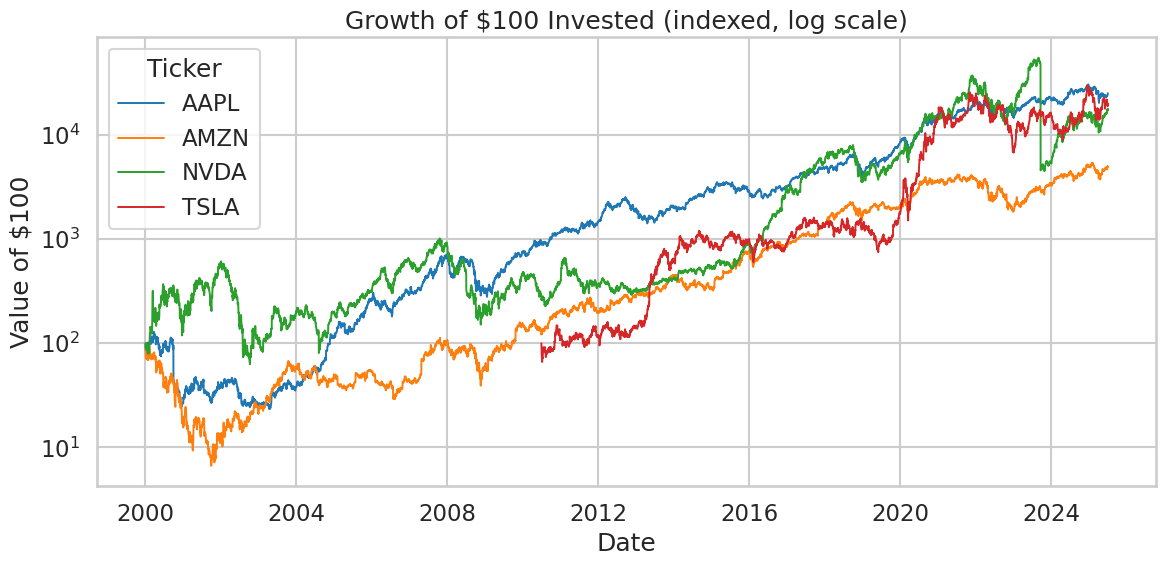

In [ ]:
stock['Indexed'] = stock.groupby('Ticker')['Close'].transform(lambda s: s / s.iloc[0] * 100)
plt.figure(figsize=(12, 6))
sns.lineplot(data=stock, x='Date', y='Indexed', hue='Ticker', palette=PALETTE, linewidth=1.4)
plt.yscale('log')
plt.title("Growth of $100 Invested (indexed, log scale)")
plt.ylabel("Value of $100"); plt.xlabel("Date")
plt.tight_layout(); plt.show()

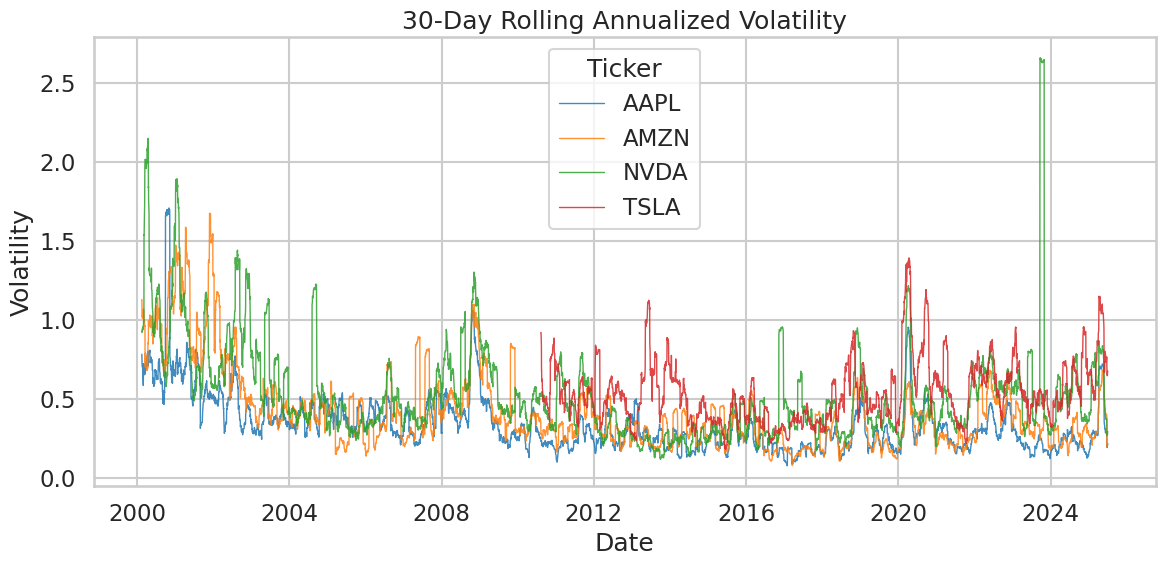

In [ ]:
stock['Return'] = stock.groupby('Ticker')['Close'].pct_change()
stock['Vol30']  = stock.groupby('Ticker')['Return'].transform(lambda s: s.rolling(30).std() * np.sqrt(252))
plt.figure(figsize=(12, 6))
sns.lineplot(data=stock, x='Date', y='Vol30', hue='Ticker', palette=PALETTE, linewidth=1.0, alpha=0.85)
plt.title("30-Day Rolling Annualized Volatility")
plt.ylabel("Volatility"); plt.xlabel("Date")
plt.tight_layout(); plt.show()

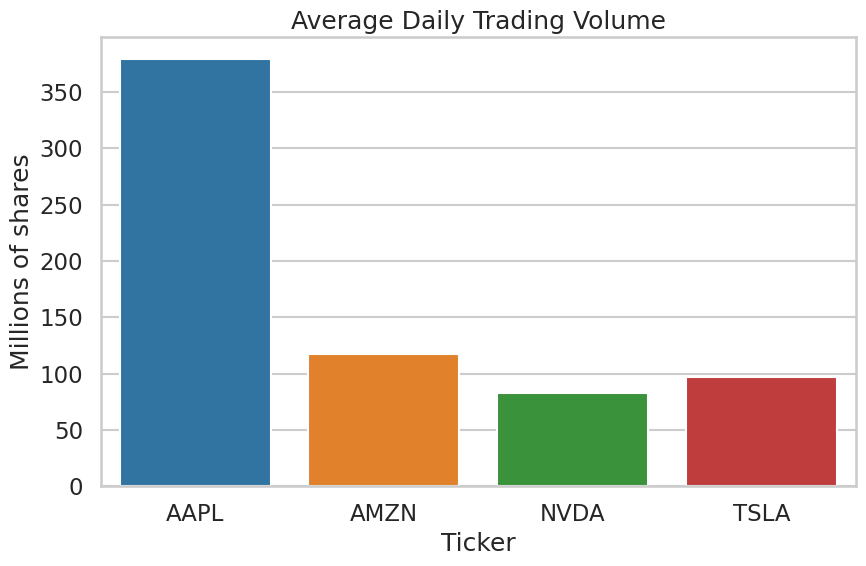

In [ ]:
avg = stock.groupby('Ticker', as_index=False)['Volume'].mean()
avg['Volume'] /= 1e6
plt.figure(figsize=(9, 6))
sns.barplot(data=avg, x='Ticker', y='Volume', hue='Ticker', palette=PALETTE, order=TICKERS, legend=False)
plt.title("Average Daily Trading Volume")
plt.ylabel("Millions of shares"); plt.xlabel("Ticker")
plt.tight_layout(); plt.show()

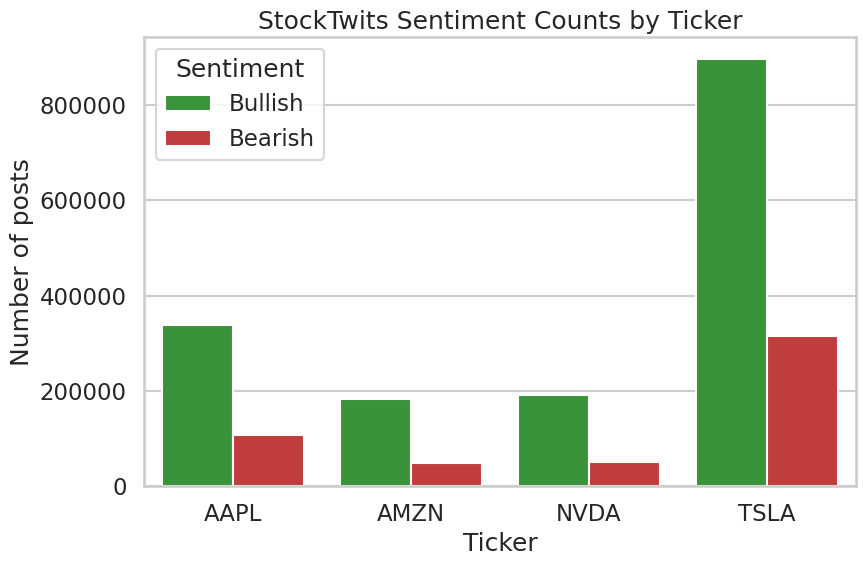

In [ ]:
plt.figure(figsize=(9, 6))
sns.countplot(data=posts, x='Ticker', hue='Sentiment', order=TICKERS,
              palette={'Bullish':'#2ca02c', 'Bearish':'#d62728'})
plt.title("StockTwits Sentiment Counts by Ticker")
plt.ylabel("Number of posts"); plt.xlabel("Ticker")
plt.tight_layout(); plt.show()

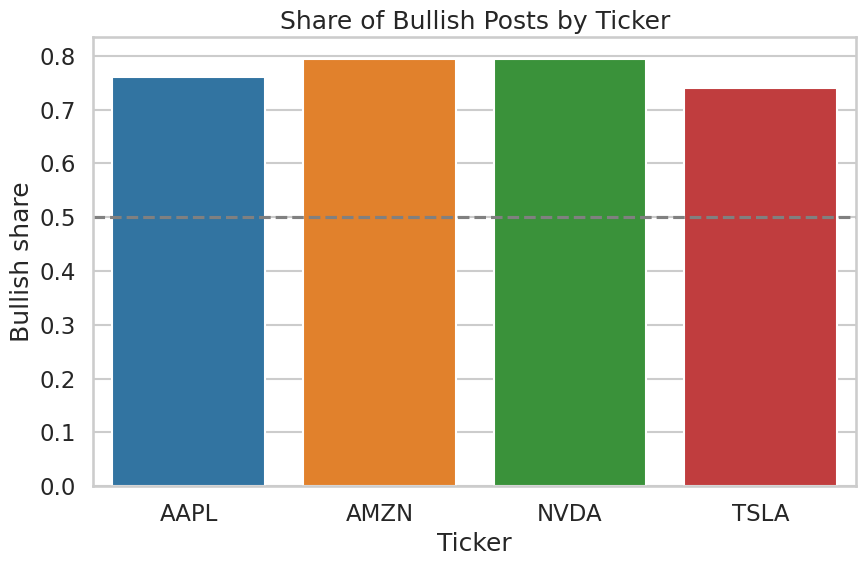

In [ ]:
ratio = (posts.assign(is_bull=posts['Sentiment'].eq('Bullish'))
              .groupby('Ticker')['is_bull'].mean()
              .reindex(TICKERS).reset_index())
plt.figure(figsize=(9, 6))
sns.barplot(data=ratio, x='Ticker', y='is_bull', hue='Ticker', palette=PALETTE, order=TICKERS, legend=False)
plt.axhline(0.5, ls='--', color='grey')
plt.title("Share of Bullish Posts by Ticker")
plt.ylabel("Bullish share"); plt.xlabel("Ticker")
plt.tight_layout(); plt.show()

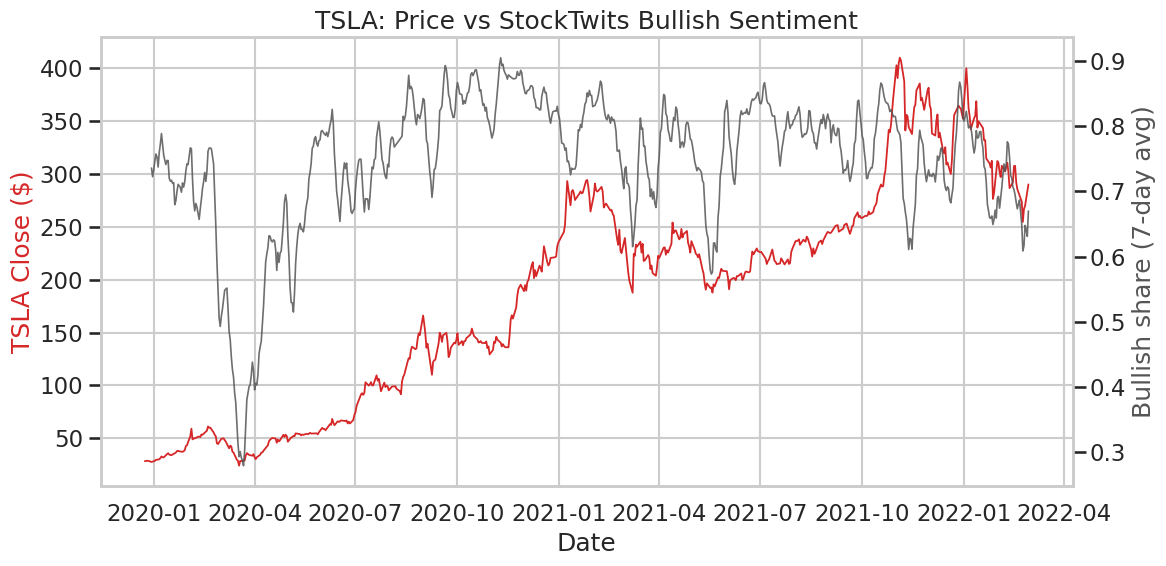

In [ ]:
TICKER = 'TSLA'   # ig i need to change to compare other stocks
s = posts[posts['Ticker'] == TICKER].copy()
s['is_bull'] = s['Sentiment'].eq('Bullish')
daily = s.groupby(s['Date'].dt.date)['is_bull'].mean().rolling(7).mean()
daily.index = pd.to_datetime(daily.index)

p = stock[stock['Ticker'] == TICKER].set_index('Date')['Close']
p = p[(p.index >= daily.index.min()) & (p.index <= daily.index.max())]

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(x=p.index, y=p.values, ax=ax1, color=PALETTE[TICKER], linewidth=1.3)
ax1.set_ylabel(f"{TICKER} Close ($)", color=PALETTE[TICKER]); ax1.set_xlabel("Date")
ax2 = ax1.twinx()
sns.lineplot(x=daily.index, y=daily.values, ax=ax2, color='#555', linewidth=1.2, alpha=0.85)
ax2.set_ylabel("Bullish share (7-day avg)", color='#555'); ax2.grid(False)
ax1.set_title(f"{TICKER}: Price vs StockTwits Bullish Sentiment")
plt.tight_layout(); plt.show()


## NLP and stock movement prediction (Akzel )

- Calculate the probability of whether a stock's price will move UP or DOWN tomorrow based on market metrics and social media sentiment.



## K-means optimization (Jasleen, Shana )
- sort the data to groups so we can tell how a stock price moved based on what people were saying on stocktwits on a specific day


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

lab = posts[posts['Sentiment'].isin(['Bullish', 'Bearish'])].copy()
lab['Date'] = lab['Date'].dt.normalize()
daily_sent = lab.groupby(['Ticker', 'Date']).agg(
    Bullish=('Sentiment', lambda s: (s == 'Bullish').sum()),
    Bearish=('Sentiment', lambda s: (s == 'Bearish').sum()),
).reset_index()
daily_sent['Labeled_Posts']   = daily_sent['Bullish'] + daily_sent['Bearish']
daily_sent['Bullish_Ratio']   = daily_sent['Bullish'] / daily_sent['Labeled_Posts']
daily_sent['Log_Post_Volume'] = np.log1p(daily_sent['Labeled_Posts'])

s = stock.sort_values(['Ticker', 'Date']).copy()
s['Date'] = s['Date'].dt.normalize()
s['Daily_Return']    = s.groupby('Ticker')['Close'].pct_change()
s['Next_Day_Return'] = s.groupby('Ticker')['Close'].shift(-1) / s['Close'] - 1
s['Intraday_Range']  = (s['High'] - s['Low']) / s['Open']

features = ['Bullish_Ratio', 'Log_Post_Volume', 'Daily_Return', 'Next_Day_Return', 'Intraday_Range']
df = daily_sent.merge(s[['Ticker', 'Date'] + features[2:]], on=['Ticker', 'Date'], how='inner')
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=features).reset_index(drop=True)

X = StandardScaler().fit_transform(df[features])
print("Feature table:", df.shape)
df.head()

Feature table: (3706, 10)


,Ticker,Date,Bullish,Bearish,Labeled_Posts,Bullish_Ratio,Log_Post_Volume,Daily_Return,Next_Day_Return,Intraday_Range
0,AAPL,2019-12-31,44,9,53,0.830189,3.988984,0.007307,0.022816,0.014348
1,AAPL,2020-01-02,754,189,943,0.799576,6.850126,0.022816,-0.009722,0.018262
2,AAPL,2020-01-03,406,214,620,0.654839,6.431331,-0.009722,0.007968,0.013730
3,AAPL,2020-01-06,270,104,374,0.721925,5.926926,0.007968,-0.004703,0.024541
4,AAPL,2020-01-07,338,185,523,0.646272,6.261492,-0.004703,0.016086,0.011406


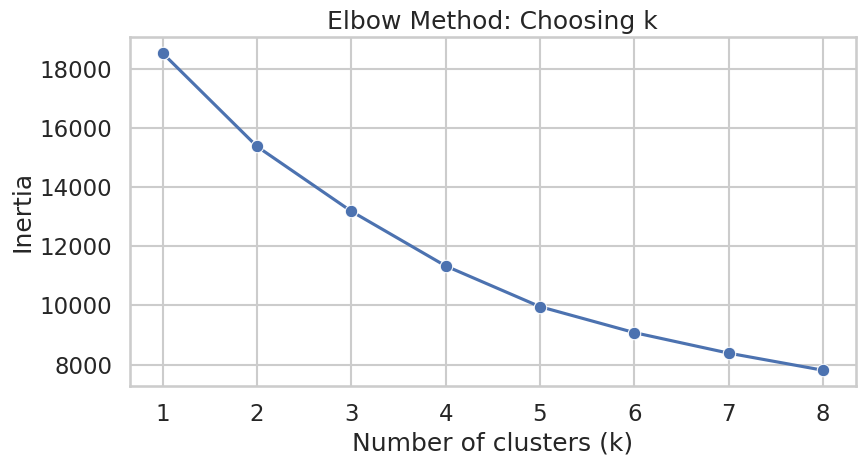

In [ ]:
ks = range(1, 9)
inertia = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_ for k in ks]
plt.figure(figsize=(9, 5))
sns.lineplot(x=list(ks), y=inertia, marker='o')
plt.title("Elbow Method: Choosing k")
plt.xlabel("Number of clusters (k)"); plt.ylabel("Inertia")
plt.tight_layout(); plt.show()

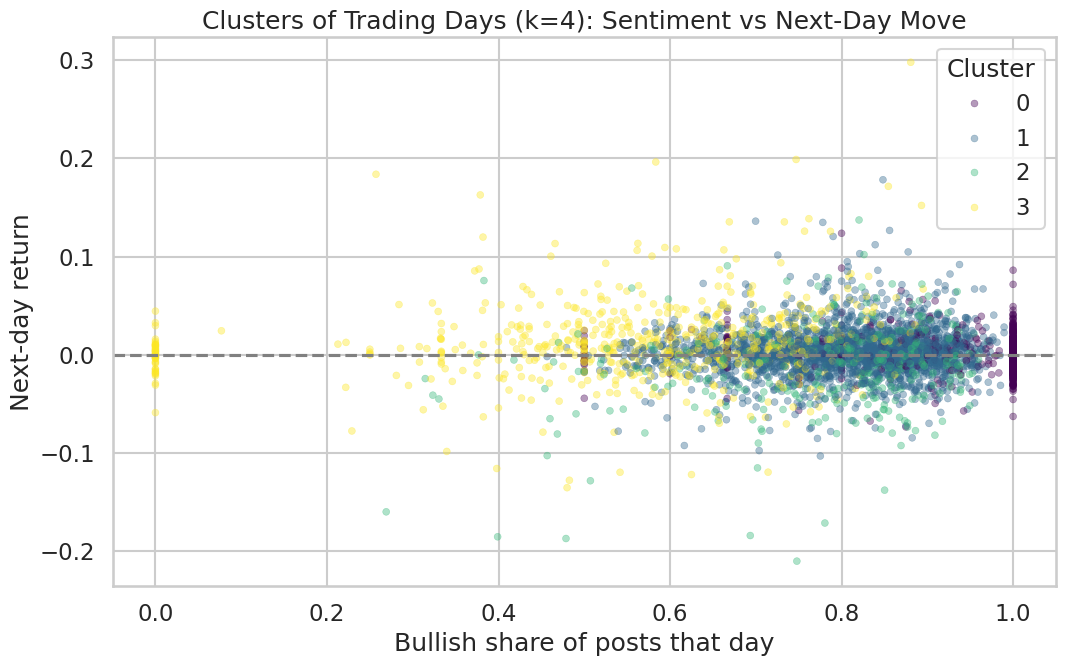

In [ ]:
k = 4   # i mean i can use k=3 also, its just the value where the albow bends

df['Cluster'] = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X)

plt.figure(figsize=(11, 7))
sns.scatterplot(data=df, x='Bullish_Ratio', y='Next_Day_Return', hue='Cluster',
                palette='viridis', alpha=0.4, s=25, edgecolor=None)
plt.axhline(0, ls='--', color='grey')
plt.title(f"Clusters of Trading Days (k={k}): Sentiment vs Next-Day Move")
plt.xlabel("Bullish share of posts that day"); plt.ylabel("Next-day return")
plt.tight_layout(); plt.show()

In [ ]:
summary = df.groupby('Cluster').agg(
    Days=('Cluster', 'size'),
    Bullish_Ratio=('Bullish_Ratio', 'mean'),
    Log_Post_Volume=('Log_Post_Volume', 'mean'),
    Daily_Return=('Daily_Return', 'mean'),
    Next_Day_Return=('Next_Day_Return', 'mean'),
    Intraday_Range=('Intraday_Range', 'mean'),
).round(4)
summary


,Days,Bullish_Ratio,Log_Post_Volume,Daily_Return,Next_Day_Return,Intraday_Range
Cluster,,,,,,
0,624,0.9357,1.7642,0.0051,0.0017,0.0223
1,2119,0.8028,5.5370,0.0038,0.0022,0.0241
2,349,0.7810,6.6097,0.0512,-0.0130,0.0659
3,614,0.5510,5.3216,-0.0305,0.0125,0.0483
